
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://i.postimg.cc/vBPDms4J/pythonml-2.png" >
      </a>

**Follow with these videos:**
* Classification Metrics (1) :  https://youtu.be/AzKl725nKlo?si=cjEOeJyRFHWyF8zh

* Classification Metrics (2) :  https://youtu.be/j1yQVecBYIc?si=uVMGwHH9sZgZgzqb



In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# change plotly style
import plotly.io as pio
pio.templates.default = "presentation"

# Classification Metrics

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
X = iris.data.values[:55, :]
y = iris.target[:55]

In [5]:
y.value_counts()

target
0    50
1     5
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [7]:
y_train.value_counts(), y_test.value_counts()

(target
 0    37
 1     4
 Name: count, dtype: int64,
 target
 0    13
 1     1
 Name: count, dtype: int64)

In [8]:
# Most Frequent Class
y_train.mode()[0], y_test.mode()[0]

(0, 0)

# Dummy Classifier


In [9]:
Train_Accuracy = y_train.value_counts()[y_train.mode()[0]] / len(y_train)
Test_Accuracy = y_test.value_counts()[y_test.mode()[0]] / len(y_test)

print(" Train Accuracy: ", Train_Accuracy)
print(" Test Accuracy: ", Test_Accuracy)

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


In [10]:
from sklearn.base import BaseEstimator
class DummyClassifier(BaseEstimator):
    def fit(self, X, y):
        return self
    def predict(self, X):
        # return the most frequent class
        return np.full((len(X), 1), y_train.mode()[0])

In [11]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score

print(" Train Accuracy: ", accuracy_score(y_train, dummy_clf.predict(X_train)))
print(" Test Accuracy: ", accuracy_score(y_test, y_pred))

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


In [13]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

print(" Train Accuracy: ", accuracy_score(y_train, dummy_clf.predict(X_train)))
print(" Test Accuracy: ", accuracy_score(y_test, y_pred))

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


# Confusion Matrix


In [14]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[13,  0],
       [ 1,  0]], dtype=int64)

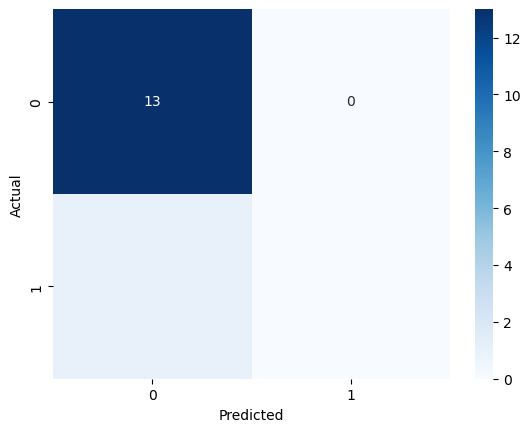

In [15]:
# plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

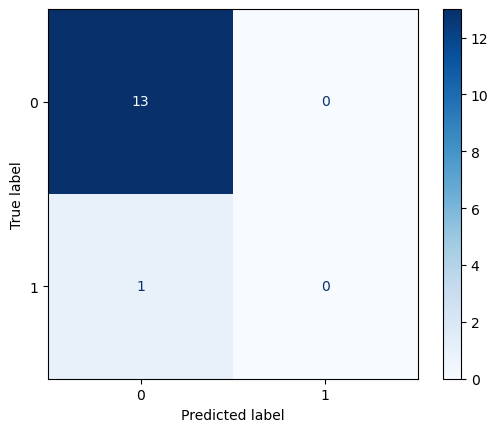

In [16]:
# Confusion Matrix Display
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')

In [17]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('True Negatives:', tn)
print('False Positives:', fp)
print('False Negatives:', fn)
print('True Positives:', tp)

True Negatives: 13
False Positives: 0
False Negatives: 1
True Positives: 0


# Precision


In [18]:
from sklearn.metrics import precision_score

print(" Precision: ", precision_score(y_test, y_pred))
print(" Precision_0: ", precision_score(y_test, y_pred, pos_label=0))

 Precision:  0.0
 Precision_0:  0.9285714285714286


c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Recall


In [19]:
from sklearn.metrics import recall_score
print(" Recall: ", recall_score(y_test, y_pred))
print(" Recall_0: ", recall_score(y_test, y_pred, pos_label=0))

 Recall:  0.0
 Recall_0:  1.0


# F1 Score


In [20]:
from sklearn.metrics import f1_score
print(" F1 Score: ", f1_score(y_test, y_pred))
print(" F1 Score_0: ", f1_score(y_test, y_pred, pos_label=0))

 F1 Score:  0.0
 F1 Score_0:  0.962962962962963


# Classification Report


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       0.00      0.00      0.00         1

    accuracy                           0.93        14
   macro avg       0.46      0.50      0.48        14
weighted avg       0.86      0.93      0.89        14



# Multiclass Classification Metrics

In [22]:
X = iris.data.values
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [23]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

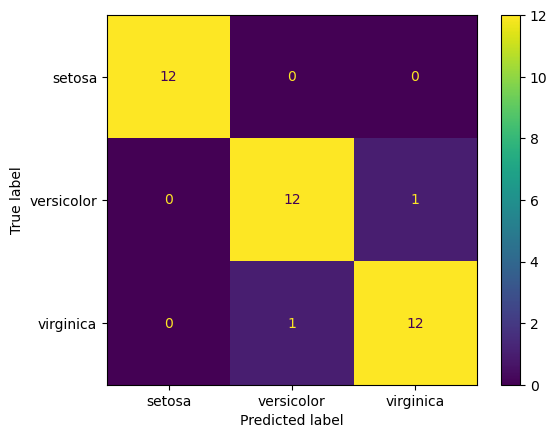

In [24]:
# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names).plot()

In [25]:
# precision, recall, f1-score
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [26]:
print(precision_score(y_test, y_pred, average=None))
print(recall_score(y_test, y_pred, average=None))
print(f1_score(y_test, y_pred, average=None))

[1.         0.92307692 0.92307692]
[1.         0.92307692 0.92307692]
[1.         0.92307692 0.92307692]


In [27]:
print(precision_score(y_test, y_pred, average='macro'))
print(recall_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))

0.9487179487179488
0.9487179487179488
0.9487179487179488


In [28]:
print(precision_score(y_test, y_pred, average='micro'))
print(recall_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='micro'))

0.9473684210526315
0.9473684210526315
0.9473684210526315


In [29]:
print(precision_score(y_test, y_pred, average='weighted'))
print(recall_score(y_test, y_pred, average='weighted'))
print(f1_score(y_test, y_pred, average='weighted'))

0.9473684210526315
0.9473684210526315
0.9473684210526315


# MNIST Dataset

In [30]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

mnist.keys()

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [31]:
X, y = mnist.data, mnist.target
X.shape, y.shape

((70000, 784), (70000,))

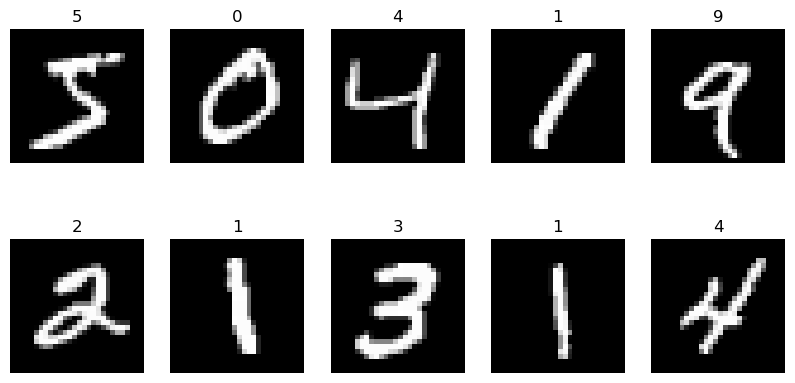

In [32]:
# plot some images
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(y[i])
    ax.axis('off')
plt.show()



In [33]:
# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [34]:
X_train.shape, X_test.shape

((52500, 784), (17500, 784))

In [35]:
# Binary Classification (5 or not 5)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [36]:
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train_5)
y_pred = clf.predict(X_test)

c:\Users\ahmad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


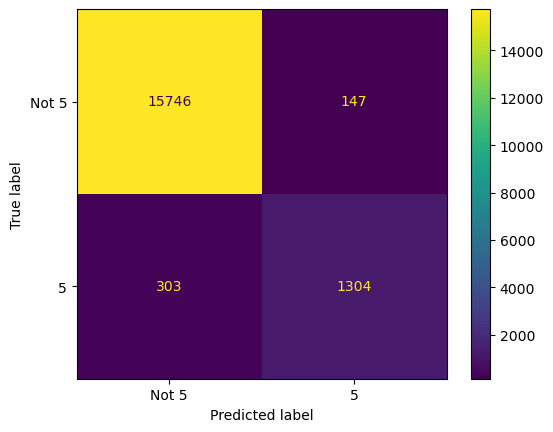

In [37]:
# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_5, y_pred), display_labels=['Not 5', '5']).plot()

In [38]:
print(classification_report(y_test_5, y_pred, target_names=['Not 5', '5']))

              precision    recall  f1-score   support

       Not 5       0.98      0.99      0.99     15893
           5       0.90      0.81      0.85      1607

    accuracy                           0.97     17500
   macro avg       0.94      0.90      0.92     17500
weighted avg       0.97      0.97      0.97     17500



# Precision vs Recall Tradeoff

In [39]:
# Probability Estimation
y_proba = clf.predict_proba(X_test)

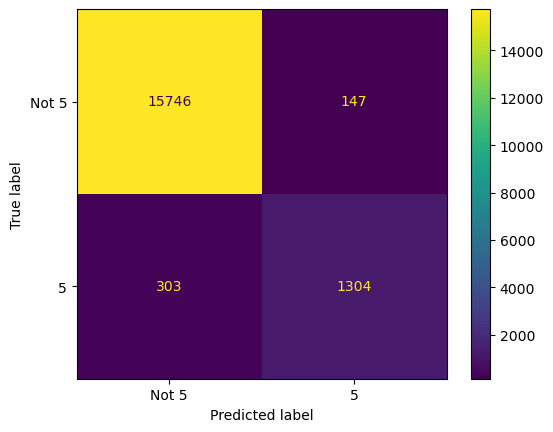

In [40]:
# Threshold = 0.5
y_pred = (y_proba[:, 1] >= 0.5)

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_5, y_pred), display_labels=['Not 5', '5']).plot()

              precision    recall  f1-score   support

       Not 5       0.95      1.00      0.98     15893
           5       0.97      0.53      0.69      1607

    accuracy                           0.96     17500
   macro avg       0.96      0.76      0.83     17500
weighted avg       0.96      0.96      0.95     17500



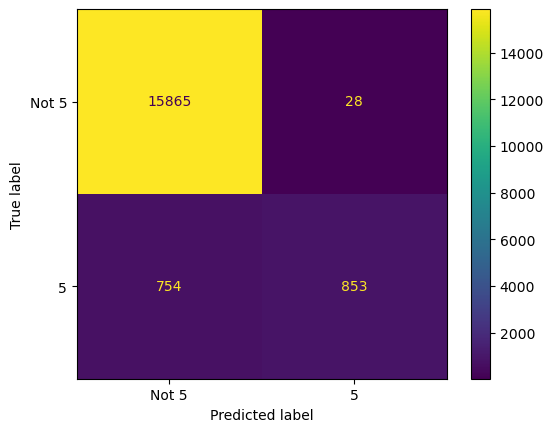

In [41]:
# Threshold = 0.9 (more strict) (more false negatives, less false positives) (less recall, more precision)
y_pred = (y_proba[:, 1] >= 0.9)

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_5, y_pred), display_labels=['Not 5', '5']).plot()

# Classification Report
print (classification_report(y_test_5, y_pred, target_names=['Not 5', '5']))

              precision    recall  f1-score   support

       Not 5       0.99      0.95      0.97     15893
           5       0.65      0.93      0.77      1607

    accuracy                           0.95     17500
   macro avg       0.82      0.94      0.87     17500
weighted avg       0.96      0.95      0.95     17500



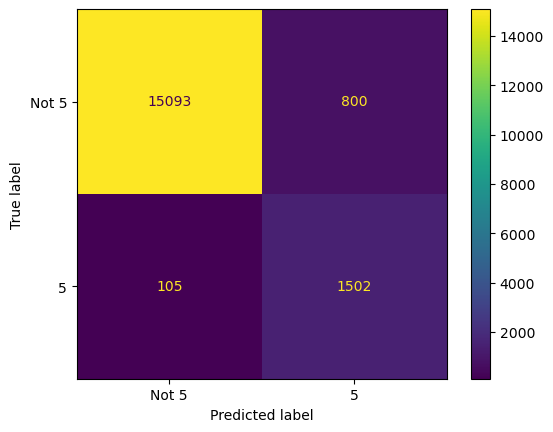

In [42]:
# Threshold = 0.1  (more false positives, less false negative) (more recall, less precision)
y_pred = (y_proba[:, 1] >= 0.1)

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_5, y_pred), display_labels=['Not 5', '5']).plot()

# Classification Report
print (classification_report(y_test_5, y_pred, target_names=['Not 5', '5']))

# Precision-Recall Curve


In [43]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test_5, y_proba[:, 1])   # n_thresholds = len(np.unique(y_proba)).

# Float Format
pd.options.display.float_format = '{:,.10f}'.format

# DataFrame
df = pd.DataFrame({'Threshold': thresholds, 'Precision': precisions[:-1], 'Recall': recalls[:-1]})
df.sample(10)


,Threshold,Precision,Recall
7210,0.0004523173,0.1542274052,0.9875544493
13569,0.0209008133,0.3945560926,0.9651524580
12275,0.0089804615,0.3000956938,0.9757311761
10199,0.0026572997,0.2168196138,0.9850653391
13523,0.0202774306,0.3899924566,0.9651524580
16215,0.6532005432,0.9322957198,0.7454884879
2738,0.0000048772,0.1083186560,0.9950217797
13600,0.0212687117,0.3976923077,0.9651524580
1530,0.0000002216,0.1004383219,0.9981331674
515,0.0000000002,0.0945540183,0.9993777225


In [44]:
# Precision vs Threshold
px.line(df, x='Threshold', y='Precision', title='Precision vs Threshold', width=800, height=600)

In [45]:
# Recall vs Threshold
px.line(df, x='Threshold', y='Recall', title='Recall vs Threshold', width=800, height=600)

In [46]:
# Precision-Recall Curve
px.line(df, x='Recall', y='Precision', title='Precision-Recall Curve', width=800, height=600, hover_data=['Threshold'])

In [47]:
# Find Threshold with Precision >= 0.9
threshold = df.loc[df['Precision'] >= 0.9, 'Threshold'].min()

print('Threshold: ', threshold)
print('Precision: ', df.loc[df['Threshold'] == threshold, 'Precision'].values[0])
print('Recall: ', df.loc[df['Threshold'] == threshold, 'Recall'].values[0])

Threshold:  0.5070352261714044
Precision:  0.9002079002079002
Recall:  0.8083385189794648


In [48]:
# Find Threshold with Recall >= 0.9
threshold = df.loc[df['Recall'] >= 0.9, 'Threshold'].max()

print('Threshold: ', threshold)
print('Precision: ', df.loc[df['Threshold'] == threshold, 'Precision'].values[0])
print('Recall: ', df.loc[df['Threshold'] == threshold, 'Recall'].values[0])

Threshold:  0.2122606930124909
Precision:  0.78470715835141
Recall:  0.9004355942750467


# ROC Curve

In [49]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_5, y_proba[:, 1])

# DataFrame
df = pd.DataFrame({'Threshold': thresholds, 'FPR': fpr, 'TPR': tpr})
df.sample(10)

,Threshold,FPR,TPR
254,0.4572540667,0.0105077707,0.8276291226
192,0.5783060409,0.0071100484,0.7797137523
352,0.2974521574,0.0180582646,0.8767890479
163,0.6487650677,0.0056628704,0.7479775980
290,0.3888243485,0.0134021267,0.8500311139
672,0.0001514327,0.6373875291,0.9900435594
467,0.1335300973,0.0399546970,0.9259489732
374,0.2568866662,0.0215818285,0.8848786559
375,0.2566835234,0.0216447493,0.8848786559
516,0.0733748851,0.0642421192,0.9415059116


In [50]:
# ROC Curve
px.line(df, x='FPR', y='TPR', title='ROC Curve', width=800, height=600, hover_data=['Threshold'])


# ROC AUC Score

In [51]:
# AUC
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test_5, y_proba[:, 1])

0.9777195824706849

In [52]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier

clf = DummyClassifier(strategy='most_frequent')
clf.fit(X_train, y_train_5)
y_proba_dummy = clf.predict_proba(X_test)

In [53]:
# ROC Curve
fpr_dummy, tpr_dummy, thresholds_dummy = roc_curve(y_test_5, y_proba_dummy[:, 1])

# plot
fig = px.line(df, x='FPR', y='TPR', title='ROC Curve', width=800, height=600, hover_data=['Threshold'])
fig.add_scatter(x=fpr_dummy, y=tpr_dummy, mode='lines', name='Dummy Classifier', line=dict(dash='dash'))
fig.show()

In [54]:
# Compare Logistic Regression and RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train, y_train_5)
y_proba_rf = rf_clf.predict_proba(X_test)

In [55]:
# ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_5, y_proba_rf[:, 1])

# plot
fig = px.line(df, x='FPR', y='TPR', title='ROC Curve', width=800, height=600, hover_data=['Threshold'])
fig.add_scatter(x=fpr_dummy, y=tpr_dummy, mode='lines', name='Dummy Classifier', line=dict(dash='dash'))
fig.add_scatter(x=fpr_rf, y=tpr_rf, mode='lines', name='RandomForestClassifier', marker=dict(color='red'))
fig.show()